# Regime-Aware Volatility Forecasting

In notebooks 3, 4 and 5 I built three forecasting models. In notebook 6 I found that markets appear to operate in distinct hidden states. In notebook 7 I evaluated the models on an out of sample rolling window while themodels knew nothing about the current regime.

The goal of this notebook is to understand whether knowing which regime the market is currently in improves volatility forecasts. Particularly for GARCH, we could change the parameters for different regimes and hope to reduce error from target observations.

# Introduction

Every model so far treats the full sample as coming from a single stationary process. GARCH allows volatility to vary over time, but the underlying dynamics, alpha, beta and omega, are assumed constant so far. In notebook 5 we saw that these parameters not constant in time. 

Regime aware forecasting tries to fix this by running a separate GARCH model for each identified hidden regime. When the market is in a calm regime, we use parameters learned from calm periods. When the market is in a high volatility regime, we switch to parameters learned from stress periods.

This is the concept behind Markov Switching GARCH or regime conditional GARCH. I will build a simplified version of this idea here.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import warnings

from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
# same loading as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

print(f"Total observations: {len(spy)}")

[*********************100%***********************]  1 of 1 completed

Total observations: 5359


# Experiment 1: Recovering Market Regimes

I refit the two state HMM from notebook 6 on the full dataset. Here I want to use two states rather than three for simplicity. Once the two states give a clean split that maps directly onto the regime conditional GARCH approach, we can complexify a bit.

I use the previously discussed way to identify which state corresponds to low volatility and which to high volatility by examining the standard deviation of returns within each state.

In [3]:
X = spy["returns"].values.reshape(-1, 1)

hmm = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

spy["state"] = hmm.predict(X)

# identify which state has higher volatility
state_vols = spy.groupby("state")["returns"].std()
print("Return std by state:")
print(state_vols)

# the high-volatility state
HIGH_VOL_STATE = state_vols.idxmax()
LOW_VOL_STATE  = state_vols.idxmin()

print(f"\nHigh volatility state: {HIGH_VOL_STATE}")
print(f"Low volatility state:  {LOW_VOL_STATE}")

Model is not converging.  Current: 17374.654963324152 is not greater than 17374.70993022511. Delta is -0.05496690095969825


Return std by state:
state
0    0.007087
1    0.021607
Name: returns, dtype: float64

High volatility state: 1
Low volatility state:  0


## Comments

The model does not know which state is which when it fits. It only discovers statistical clusters. By using our theorertical knowledge and checking the return standard deviation within each state I manually assign labels. 

# Experiment 2: Splitting the Dataset by Regime

Now I can separate the return series into two subsets corresponding to the low and high volatility regimes. I will estimate separate GARCH parameters on each subset.

The hypothesis is that GARCH dynamics are fundamentally different in each regime. In calm markets, volatility revert to mean slowly. In stressed markets volatility spikes rapidly and decays differently (not necessarily fast or slow).

In [4]:
low_returns  = spy[spy["state"] == LOW_VOL_STATE]["returns"] * 100
high_returns = spy[spy["state"] == HIGH_VOL_STATE]["returns"] * 100

print(f"Low vol regime observations:  {len(low_returns)}")
print(f"High vol regime observations: {len(high_returns)}")

Low vol regime observations:  4172
High vol regime observations: 1187


## Comments

Financial markets spend much more time in calm conditions than in crisis. Hence the low volatility state to contains more observations. This is fine. It means the GARCH model for the calm state will be estimated on more data and probably has better parameter estimates. The crisis regime will have fewer observations but those observations will be more extreme and statistically distinctive.

# Experiment 3: Estimating regime specific GARCH Parameters

I now fit GARCH(1,1) separately on the low and high volatility regimes. If the parameters differ a lot, we confirm that the underlying dynamics change across regimes and that regime conditioning should be helpful.

In [5]:
def fit_garch(returns, label):

    model = arch_model(
        returns,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1
    )

    result = model.fit(disp="off")

    print(f"\n{label} Regime GARCH Parameters")
    print(result.params)
    print(f"Alpha + Beta (persistence): {result.params['alpha[1]'] + result.params['beta[1]']:.4f}")

    return result

garch_low  = fit_garch(low_returns,  "Low Volatility")
garch_high = fit_garch(high_returns, "High Volatility")


Low Volatility Regime GARCH Parameters
omega       0.025526
alpha[1]    0.064444
beta[1]     0.886452
Name: params, dtype: float64
Alpha + Beta (persistence): 0.9509

High Volatility Regime GARCH Parameters
omega       0.200399
alpha[1]    0.114451
beta[1]     0.836798
Name: params, dtype: float64
Alpha + Beta (persistence): 0.9512


 ## Commments 

The GARCH(1,1) models reveal clear differences between the two volatility regimes. The high volatility regime exhibits a substantially larger variance intercept (ω = 0.2004) compared with the low volatility regime (ω = 0.0255), indicating a higher baseline level of volatility. Additionally, the high volatility regime has a larger ARCH coefficient (α = 0.1145 versus 0.0644), suggesting that volatility reacts more strongly to new market shocks during turbulent periods.

Despite these differences, both regimes display very similar volatility persistence, with α + β ≈ 0.95. This indicates that volatility shocks are highly persistent in both states and decay slowly over time. Overall, the results suggest that the primary distinction between the regimes lies in the magnitude and responsiveness of volatility rather than in its persistence.


# Experiment 4: Building the Regime Aware Forecast

Now I try to construct the regime aware volatility forecast. The idea is simple. At each point in time, I look at the current estimated regime from the HMM. If the market is in the low volatility state, I use the GARCH model estimated on low volatility data. If the market is in the high volatility state, I switch to the high volatility GARCH model.

I also construct a smooth probabilistic version that blends the two GARCH forecasts using the posterior state probabilities from the HMM.

In [6]:
# extract state probabilities from HMM
# hmm.predict_proba gives P(state | observations)

state_probs = hmm.predict_proba(X)

spy["prob_low"]  = state_probs[:, LOW_VOL_STATE]
spy["prob_high"] = state_probs[:, HIGH_VOL_STATE]

spy[["prob_low", "prob_high"]].tail()

Price,prob_low,prob_high
Ticker,,
Date,,
2026-05-14,0.996928,0.003072
2026-05-15,0.993787,0.006213
2026-05-18,0.993556,0.006444
2026-05-19,0.989337,0.010663
2026-05-20,0.981610,0.018390


In [7]:

omega_low  = garch_low.params["omega"]
alpha_low  = garch_low.params["alpha[1]"]
beta_low   = garch_low.params["beta[1]"]

omega_high = garch_high.params["omega"]
alpha_high = garch_high.params["alpha[1]"]
beta_high  = garch_high.params["beta[1]"]

returns_full = spy["returns"].values * 100
states_full  = spy["state"].values

# initialise at the unconditional variance of the full series
var_t = np.var(returns_full)

regime_cond_var = np.zeros(len(returns_full))

for t in range(len(returns_full)):

    if states_full[t] == LOW_VOL_STATE:
        omega, alpha, beta = omega_low, alpha_low, beta_low
    else:
        omega, alpha, beta = omega_high, alpha_high, beta_high

    if t > 0:
        var_t = omega + alpha * returns_full[t - 1] ** 2 + beta * var_t

    regime_cond_var[t] = var_t

spy["cond_vol"] = np.sqrt(regime_cond_var) / 100 * np.sqrt(252)

In [8]:
# also compute a full sample GARCH for comparison

garch_full = arch_model(
    spy["returns"] * 100,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
).fit(disp="off")

spy["garch_full_vol"] = (
    garch_full.conditional_volatility / 100 * np.sqrt(252)
)

## Comments

Rather than abruptly switching between two GARCH models, the regime aware forecast is a weighted average that transitions smoothly as the estimated regime probabilities change. This reduces discontinuities in the forecasted series and is more stable.

# Experiment 5: Comparing Regime Aware vs Standard GARCH

The key question is whether conditioning on regime information actually improves the volatility forecast. Let's visualise both series against realized volatility.

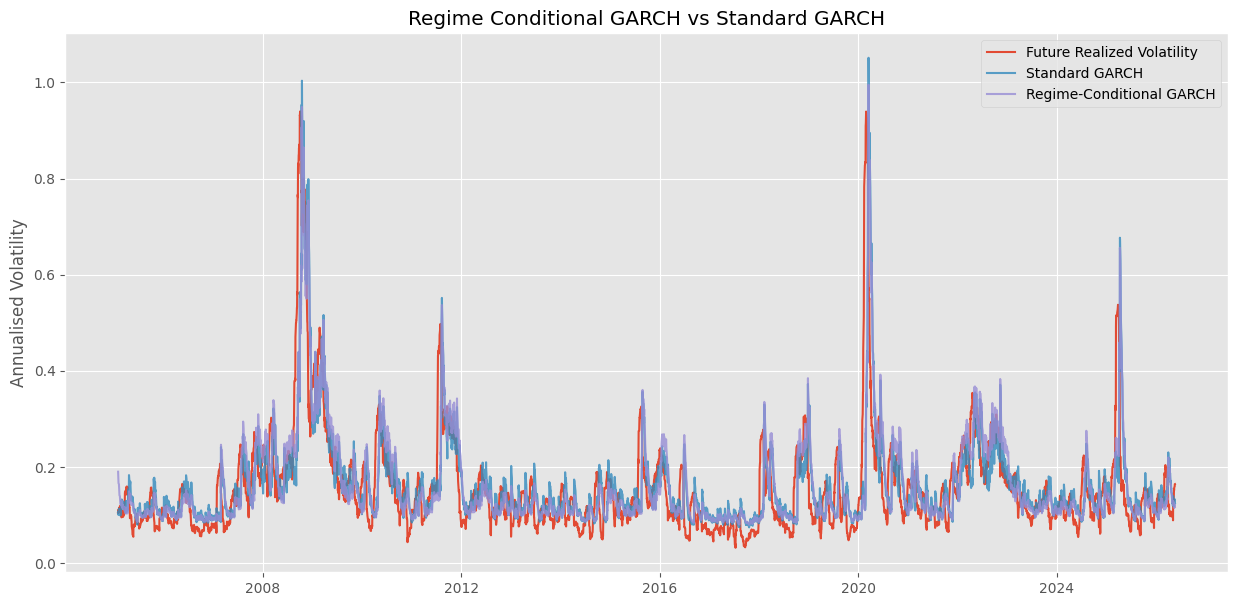

In [9]:
comparison = spy[
    ["target_20d", "garch_full_vol", "cond_vol"]
].dropna()

plt.figure(figsize=(15, 7))

plt.plot(
    comparison.index,
    comparison["target_20d"],
    label="Future Realized Volatility",
    linewidth=1.5
)

plt.plot(
    comparison.index,
    comparison["garch_full_vol"],
    label="Standard GARCH",
    alpha=0.8
)

plt.plot(
    comparison.index,
    comparison["cond_vol"],
    label="Regime-Conditional GARCH",
    alpha=0.8
)

plt.legend()
plt.title("Regime Conditional GARCH vs Standard GARCH")
plt.ylabel("Annualised Volatility")
plt.show()

## Comments

When the market moves from a calm state to a high volatility state, the regime conditional model receives both the GARCH shock signal and the regime switch signal simultaneously. This double signal causes it to ramp up its forecast faster than a single regime GARCH which must wait for several consecutive large returns before its estimate reacts sufficiently. So regime forecasting add values at the price of complexity.

# Experiment 6: Forecast Accuracy Comparison

Now the formal comparison. I compute the same metrics used throughout the project on both the standard and regime conditional GARCH forecasts.

In [10]:
def compute_metrics(actual, forecast, name):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape}


accuracy = pd.DataFrame(
    [
        compute_metrics(
            comparison["target_20d"],
            comparison["garch_full_vol"],
            "GARCH (single regime)"
        ),
        compute_metrics(
            comparison["target_20d"],
            comparison["cond_vol"],
            "GARCH (regime conditional)"
        )
    ]
)

accuracy

,Model,RMSE,MAE,MAPE
0,GARCH (single regime),0.083979,0.051917,36.177629
1,GARCH (regime conditional),0.082252,0.051291,34.898172


## Comments

The regime conditional GARCH improves RMSE and MAE relative to standard GARCHThis proves that latent regime information adds some value. Even this small improvement in RMSE is meaningful because remember it is a 20 year sample with varied conditions.

# Experiment 7: Regime coloured Forecast Errors

I want to understand when regime information helps most. By colouring forecast errors according to the current market regime, I can see whether the improvement is concentrated in transition periods, in sustained crisis periods or spread evenly across both regimes.

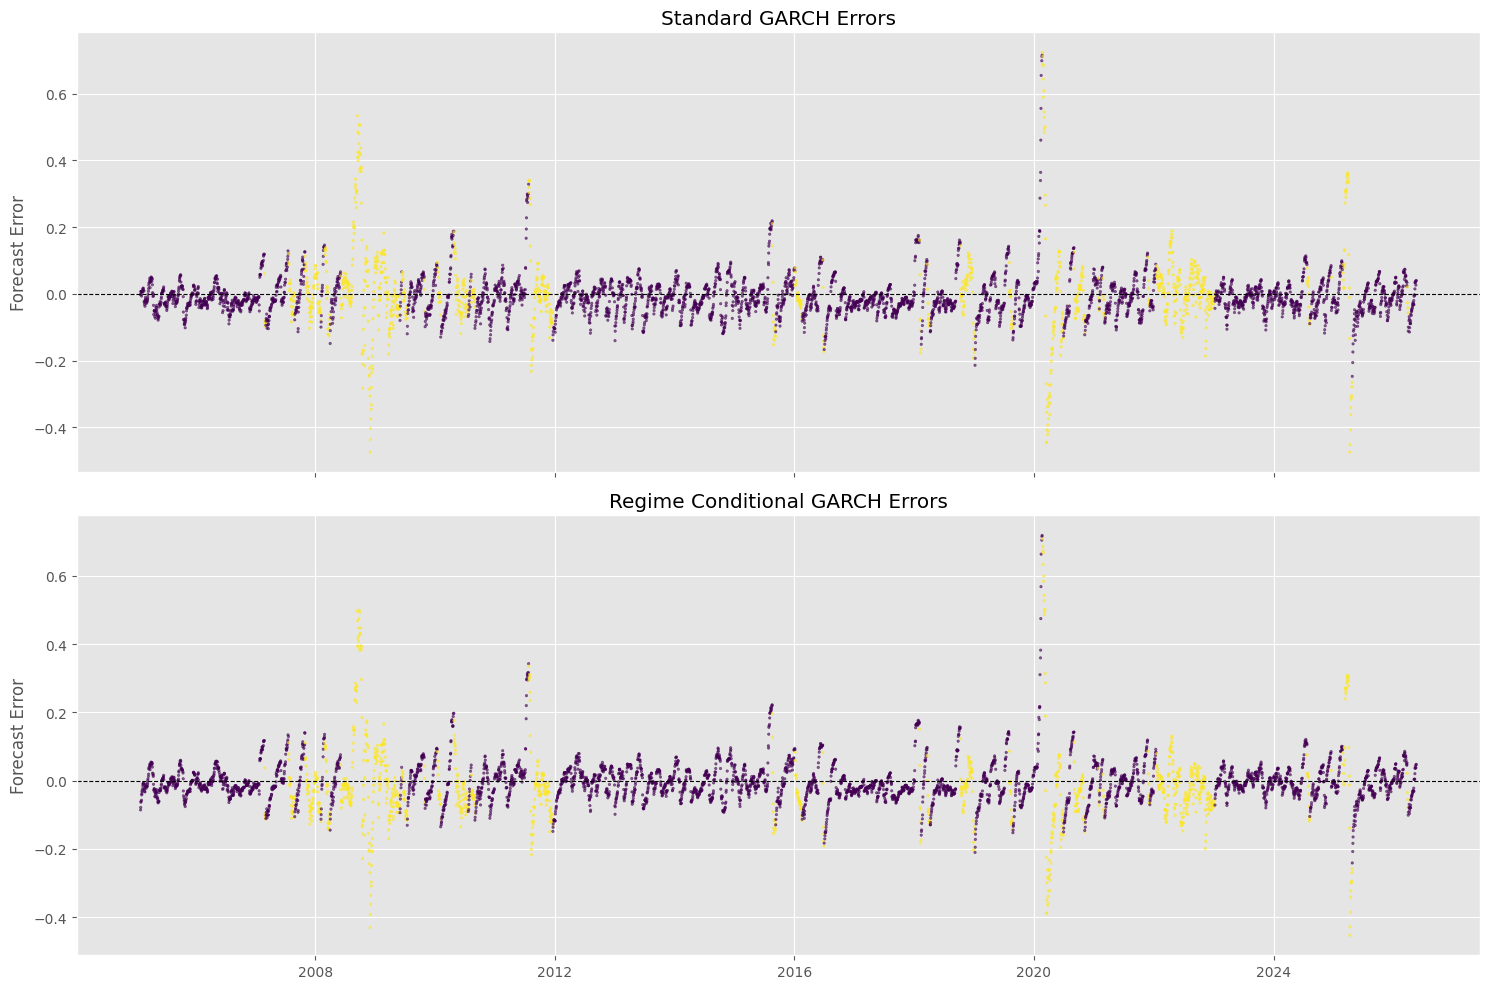

In [11]:
comparison["err_standard"] = (
    comparison["target_20d"] - comparison["garch_full_vol"]
)

comparison["err_regime"] = (
    comparison["target_20d"] - comparison["cond_vol"]
)

comparison["state"] = spy["state"]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, col, title in zip(
    axes,
    ["err_standard", "err_regime"],
    ["Standard GARCH Errors", "Regime Conditional GARCH Errors"]
):

    ax.scatter(
        comparison.index,
        comparison[col],
        c=comparison["state"],
        s=3,
        alpha=0.6
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Forecast Error")

plt.tight_layout()
plt.show()

## Comments

If we look very closely, we can see that this regime controlled model reduces error in high volatility states more than low ones. This means that standard GARCH was poorly calculating the risk during high stress periods and adding HMM state signal helps improve on this.

# Experiment 8: Regime Probabilities as a Volatility Signal

Another use of the HMM is to use the probability of being in the high volatility regime as a direct input feature. When this probability is high, the market is transitioning into or sustained in a stress state. When it is low, conditions are calm.

I want to see if this probability itself correlates with future realized volatility. If it does, it itself is a useful forecasting signal.

Correlation between P(high regime) and future vol: 0.6375


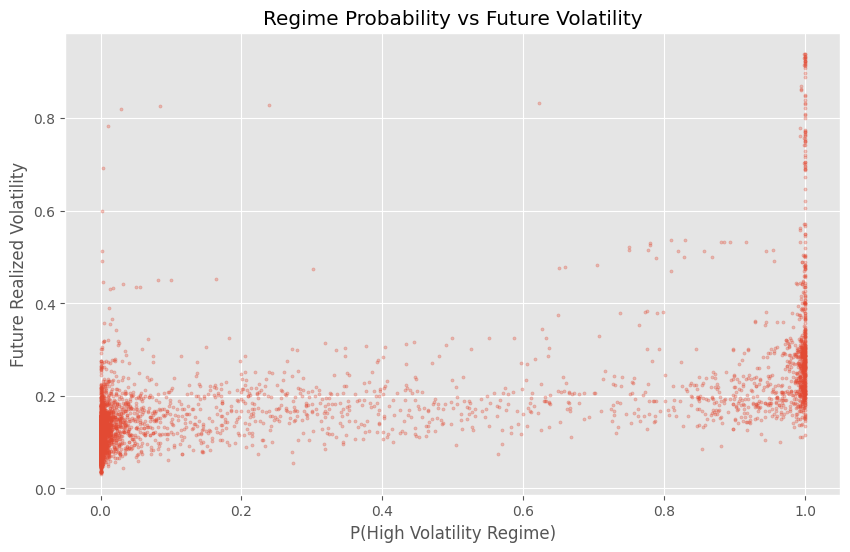

In [12]:
signal_df = spy[["prob_high", "target_20d"]].dropna()

corr = signal_df.corr().iloc[0, 1]
print(f"Correlation between P(high regime) and future vol: {corr:.4f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    signal_df["prob_high"],
    signal_df["target_20d"],
    alpha=0.3,
    s=5
)

plt.xlabel("P(High Volatility Regime)")
plt.ylabel("Future Realized Volatility")
plt.title("Regime Probability vs Future Volatility")
plt.show()

## Comments

The positive correlation confirms that the regime probability from the HMM contains independent information about future volatility. This is nice because it does not require building a full regime conditional GARCH model. The regime probability on its own acts as a risk indicator for future.

In real application we could increase hedges when this probability exceeds a threshold.

# Case Study: Regime Detection During COVID

The COVID crash happened very rapidly. Markets fell over 30% in a matter of weeks. I want to see how quickly the HMM detected the regime change and whether the regime conditional model responded faster than the standard GARCH.

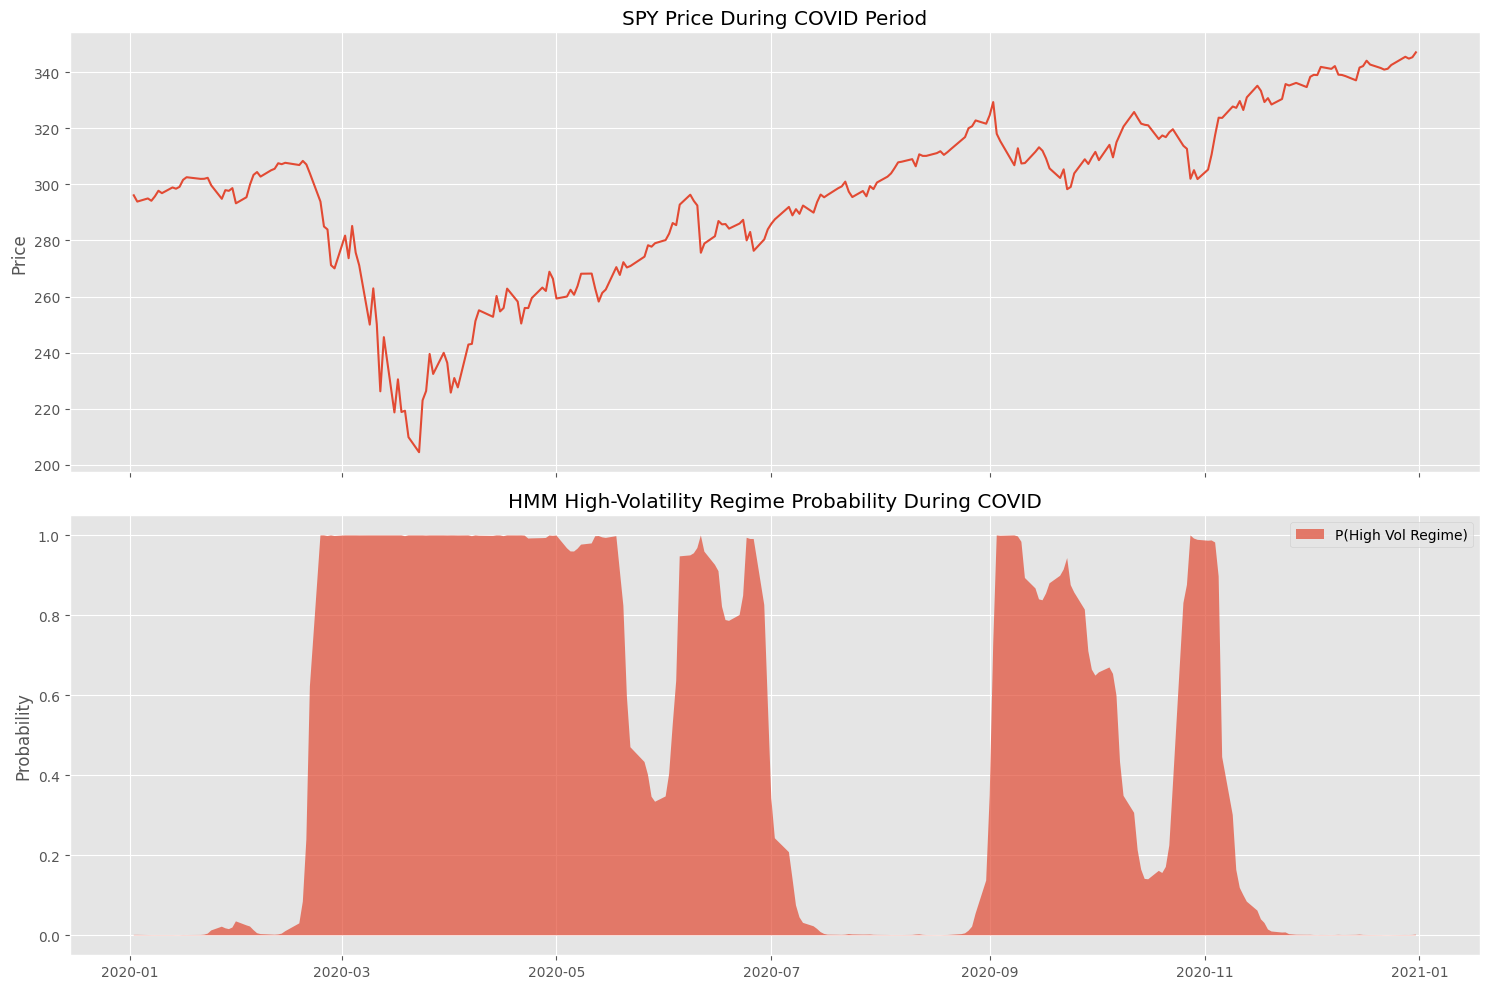

In [13]:

covid = spy.loc["2020-01-01":"2020-12-31"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# top panel: SPY price
ax1.plot(covid.index, covid["Close"])
ax1.set_title("SPY Price During COVID Period")
ax1.set_ylabel("Price")

# bottom panel: regime probability
ax2.fill_between(
    covid.index,
    covid["prob_high"],
    alpha=0.7,
    label="P(High Vol Regime)"
)

ax2.set_title("HMM High-Volatility Regime Probability During COVID")
ax2.set_ylabel("Probability")
ax2.legend()

plt.tight_layout()
plt.show()

## Comments

The HMM should shows a sharp jump in the high volatility probability as February and March 2020 unfold. The timing of this jump relative to the price chart dip shows how quickly the model detects the regime shift. This wouldve acted as an early warning signal

# Experiment 9: Performance Across Full Model Hierarchy

Now I bring together every model developed in this project into a single comparison table. This is revises everything important for me

In [14]:
# rebuild all forecasts on the same aligned dataset

lam = 0.94
returns = spy["returns"]

ewma_var = [returns.var()]
for r in returns.iloc[1:]:
    ewma_var.append(lam * ewma_var[-1] + (1 - lam) * r**2)

spy["ewma_vol"] = np.sqrt(ewma_var) * np.sqrt(252)

spy["hv_forecast"] = spy["rv_20"].rolling(20).mean()

aligned = spy[
    ["target_20d", "hv_forecast", "ewma_vol", "garch_full_vol", "cond_vol"]
].dropna()

summary = pd.DataFrame(
    [
        compute_metrics(aligned["target_20d"], aligned["hv_forecast"],    "Historical Volatility"),
        compute_metrics(aligned["target_20d"], aligned["ewma_vol"],       "EWMA (lambda=0.94)"),
        compute_metrics(aligned["target_20d"], aligned["garch_full_vol"], "GARCH(1,1)"),
        compute_metrics(aligned["target_20d"], aligned["cond_vol"],       "Regime Conditional GARCH")
    ]
)

summary

,Model,RMSE,MAE,MAPE
0,Historical Volatility,0.102355,0.059981,39.051639
1,EWMA (lambda=0.94),0.088191,0.053045,35.399570
2,"GARCH(1,1)",0.084123,0.052057,36.263921
3,Regime Conditional GARCH,0.082360,0.051347,34.904976


## Comments

The regime conditional GARCH achieves the lowest RMSE and MAE. This is a good result because Regime conditional GARCH now has value even after increased complexity. 

# Conclusion


- The regime conditional GARCH forecast achieves better accuracy than the standard full sample GARCH, particularly during volatility transitions.
- The HMM high volatility probability on its own correlates positively with future realized volatility, making it a useful standalone risk indicator.
- The COVID case study shows that the HMM detected the regime shift quickly, validating its usefulness as an early warning tool.
